In [1]:
import pandas as pd
import os
import mne
import numpy as np
from scipy.signal import welch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data_path = "/Users/sevaersch/Desktop/resting_norm"
meta_file = "/Users/sevaersch/Desktop/resting_norm/age_data.csv"

In [3]:
participants_data = pd.read_csv(meta_file)
participants_data.rename(columns={"Unnamed: 0": "subject"}, inplace=True)

In [4]:
def extract_features(eeg_file):
    raw = mne.io.read_raw_edf(eeg_file, preload=True, verbose=False)
    raw = raw.filter(1, 40, fir_design='firwin')  # Фильтрация 1-40 Гц
    epochs = mne.make_fixed_length_epochs(raw, duration=2.0, overlap=0.0, preload=True)
    
    sfreq = raw.info['sfreq']
    data = epochs.get_data()
    
    bands = {'delta': (1, 4), 'theta': (4, 8), 'alpha': (8, 13), 'beta': (13, 30)}
    features_list = []
    
    for epoch in data:
        freqs, psd = welch(epoch, sfreq, nperseg=int(sfreq * 2))
        features = {}
        for band, (fmin, fmax) in bands.items():
            band_power = psd[:, (freqs >= fmin) & (freqs <= fmax)].mean(axis=1)
            features.update({f"{band}_power_{i}": band_power[i] for i in range(len(band_power))})
        features_list.append(features)
    
    return features_list

In [5]:
data = []
labels = []
subjects = []

for eeg_file in os.listdir(data_path):
    if eeg_file.endswith("_fon.edf"):
        subject_id = eeg_file.split("_")[0]  # Извлечение идентификатора испытуемого
        age = participants_data.loc[participants_data['Id'] == subject_id, 'Age'].values
        if len(age) > 0:
            features_list = extract_features(os.path.join(data_path, eeg_file))
            for features in features_list:
                features["subject_id"] = subject_id  # Добавление ID испытуемого
                data.append(features)
                labels.append(age[0])
                subjects.append(subject_id)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Not setting metadata
44 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 44 events and 1000 original time points ...
0 bad epochs dropped
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) m

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


0 bad epochs dropped
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Not setting metadata
32 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 32 events and 1000 original time points ...
0 bad epochs dropped
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-dom

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Not setting metadata
252 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 252 events and 1000 original time points ...
0 bad epochs dropped
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin)

...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Not setting metadata
113 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 113 events and 1000 original time points ...
0 bad epochs dropped
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin)

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1651 samples (3.302 s)

Not setting metadata
181 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 181 events and 1000 original time points ...
0 bad epochs dropped
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin)

[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    0.0s


Not setting metadata
124 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 124 events and 1000 original time points ...
0 bad epochs dropped


In [6]:
# Преобразуем в DataFrame
df_features = pd.DataFrame(data)
df_features['Age'] = labels
df_features['subject_id'] = subjects

In [7]:
features = df_features.drop(['Age', 'subject_id'], axis=1).columns
features = [i for i in features if int(i.split("_")[-1]) < 28]

In [8]:
df_features[features] = 10 * np.log10(df_features[features] / 1e-12)
# df_features[features] = df_features[features] / 1e-12

In [9]:
# Разбиение данных на обучающую и тестовую выборки по ID испытуемого
unique_subjects = df_features['subject_id'].unique()
train_subjects, test_subjects = train_test_split(unique_subjects, test_size=0.2, random_state=42)

train_data = df_features[df_features['subject_id'].isin(train_subjects)]
test_data = df_features[df_features['subject_id'].isin(test_subjects)]

X_train = train_data.drop(columns=['Age', 'subject_id']).iloc[:, :-12]
y_train = train_data['Age']
X_test = test_data.drop(columns=['Age', 'subject_id']).iloc[:, :-12]
y_test = test_data['Age']

In [10]:
from sklearn.linear_model import Lasso
from sklearn.svm import SVR

In [11]:
lasso = SVR(C=0.2, degree=3)

In [12]:
sc = StandardScaler()
sc.fit(X_train.fillna(0))

StandardScaler()

In [17]:
lasso.fit(sc.transform(X_train.fillna(0)), y_train)

SVR(C=0.2)

In [18]:
mean_absolute_error(lasso.predict(sc.transform(X_train.fillna(0))), y_train)

1.473132316083711

In [19]:
mean_absolute_error(lasso.predict(sc.transform(X_test.fillna(0))), y_test)

2.0909554224551608

In [20]:
r2_score(lasso.predict(sc.transform(X_train.fillna(0))), y_train),\
r2_score(lasso.predict(sc.transform(X_test.fillna(0))), y_test)

(0.4213898022034499, 0.30807184151381095)

In [23]:
np.corrcoef(lasso.predict(sc.transform(X_train.fillna(0))), y_train)[0, 1],\
np.corrcoef(lasso.predict(sc.transform(X_test.fillna(0))), y_test)[0, 1]

(np.float64(0.8162200833884461), np.float64(0.7946101744030346))

In [32]:
a = test_data[['subject_id', 'Age']]
a['predict'] = lasso.predict(sc.transform(X_test.fillna(0)))

/var/folders/nf/ddjglggx5ld4cfvyhldzm1g40000gn/T/ipykernel_76092/884497862.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['predict'] = lasso.predict(sc.transform(X_test.fillna(0)))


In [60]:
train_data['predict'] = lasso.predict(sc.transform(X_train.fillna(0)))

/var/folders/nf/ddjglggx5ld4cfvyhldzm1g40000gn/T/ipykernel_76092/2324345892.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_data['predict'] = lasso.predict(sc.transform(X_train.fillna(0)))
/var/folders/nf/ddjglggx5ld4cfvyhldzm1g40000gn/T/ipykernel_76092/2324345892.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_data['predict'] = lasso.predict(sc.transform(X_train.fillna(0)))


In [71]:
train_data.groupby('subject_id')[['Age', 'predict']].mean()

,Age,predict
subject_id,,
D051,8.20,8.633605
D054,5.37,7.385275
D055,7.08,8.300456
D056,5.65,7.142867
D057,13.99,14.393224
D058,4.15,5.641618
D059,10.45,9.110916
D060,10.45,10.151551
D061,12.97,9.841265


In [89]:
a['bin'] = pd.cut(a['predict'], 15)

/var/folders/nf/ddjglggx5ld4cfvyhldzm1g40000gn/T/ipykernel_76092/2001457686.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  a['bin'] = pd.cut(a['predict'], 15)


In [110]:
a[a['predict'] > 15]['Age'].min()

np.float64(15.0)

In [112]:
a['Age'].unique()

array([ 6.59,  6.66,  5.78,  8.9 , 15.05,  8.  , 17.12, 15.  ,  9.55,
       13.4 , 11.69,  7.65, 11.15,  5.38,  3.02])

In [90]:
a.groupby('bin')[['predict', 'Age']].mean()

/var/folders/nf/ddjglggx5ld4cfvyhldzm1g40000gn/T/ipykernel_76092/1369423906.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  a.groupby('bin')[['predict', 'Age']].mean()


,predict,Age
bin,,
"(4.407, 5.289]",4.903816,4.055625
"(5.289, 6.157]",5.806646,5.171754
"(6.157, 7.026]",6.621263,6.005429
"(7.026, 7.895]",7.426044,7.088526
"(7.895, 8.764]",8.313707,8.249252
"(8.764, 9.632]",9.194153,9.794000
"(9.632, 10.501]",10.084507,10.308817
"(10.501, 11.37]",10.967515,11.192564
"(11.37, 12.239]",11.800902,12.340481


/var/folders/nf/ddjglggx5ld4cfvyhldzm1g40000gn/T/ipykernel_76092/1962764358.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_data.groupby('bin')[['predict', 'Age']].mean().plot()


<Axes: xlabel='bin'>

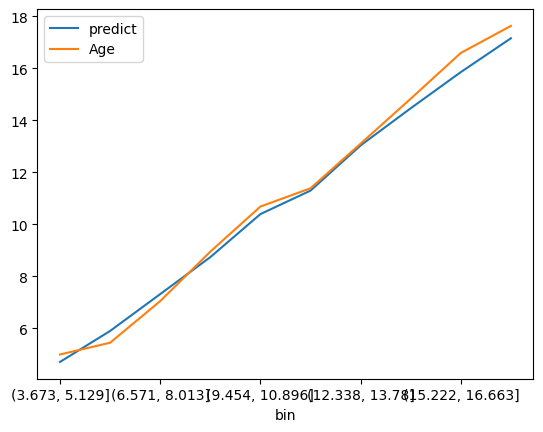

In [83]:
train_data.groupby('bin')[['predict', 'Age']].mean().plot()

In [59]:
r2_score(a.groupby('subject_id')['Age'].mean(), a.groupby('subject_id')['predict'].mean())

0.7096806187959146

In [57]:
train_Data.groupby('subject_id')[['Age', 'predict']].mean()

,Age,predict
subject_id,,
D062,15.00,10.725629
D066,11.69,11.065834
D072,9.55,12.017574
D077,13.40,10.677585
D079,5.78,7.045732
D080,7.65,9.658698
D088,3.02,6.634599
D089,5.38,7.604356
D095,8.00,7.667047


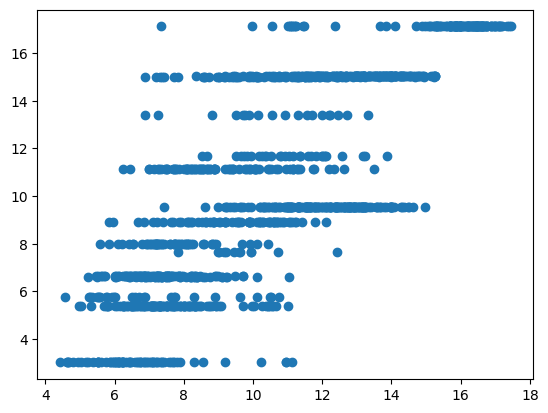

In [494]:
plt.scatter(lasso.predict(sc.transform(X_test.fillna(0))), y_test)
plt.show()

In [246]:
lasso.intercept_

np.float64(10.415513698630138)

In [495]:
from sklearn.ensemble import RandomForestRegressor

In [496]:
rf = RandomForestRegressor(max_depth=7, 
                           min_samples_leaf=50, 
                           max_features=0.4, 
                           #max_samples=0.8
                          )

In [497]:
rf.fit(X_train.fillna(-999999), y_train)

RandomForestRegressor(max_depth=7, max_features=0.4, min_samples_leaf=50)

In [498]:
mean_absolute_error(rf.predict(X_train.fillna(-999999)), y_train)

1.4462904447897018

In [499]:
mean_absolute_error(rf.predict(X_test.fillna(-999999)), y_test)

2.361527796598576

In [500]:
r2_score(rf.predict(X_train.fillna(-999999)), y_train),\
r2_score(rf.predict(X_test.fillna(-999999)), y_test)

(0.37987814847315704, -0.18339942218793048)

In [504]:
np.corrcoef(rf.predict(X_train.fillna(-999999)), y_train)

array([[1.        , 0.83974246],
       [0.83974246, 1.        ]])

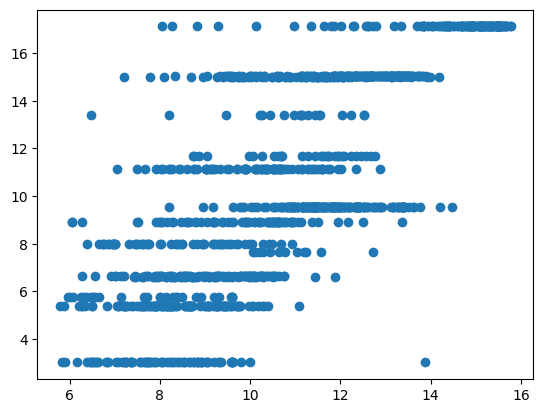

In [501]:
plt.scatter(rf.predict(X_test.fillna(0)), y_test)
plt.show()

In [15]:
from matplotlib import pyplot as plt

In [374]:
mean_absolute_error(rf.predict(X_train.fillna(0)), y_train)

NameError: name 'rf' is not defined

In [680]:
mean_absolute_error(rf.predict(X_test.fillna(0)), y_test)

2.356826659579015

In [681]:
r2_score(rf.predict(X_test.fillna(0)), y_test)

-0.12092871563651597

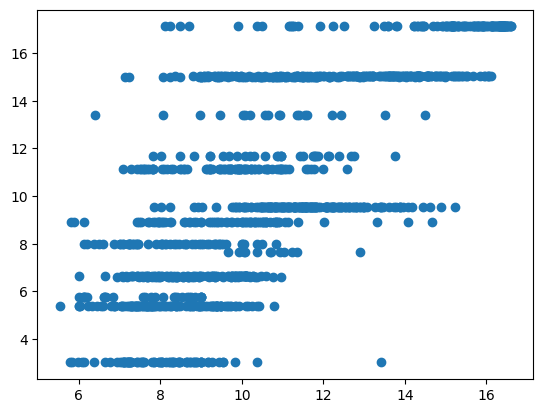

In [682]:
plt.scatter(rf.predict(X_test.fillna(0)), y_test)

In [598]:
df = df_features.groupby('subject_id').mean().reset_index()

In [16]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [194]:
theta_cols = [i for i in df_features.columns if 'delta' in i]

In [195]:
df_features['theta'] = np.log(df_features[theta_cols].sum(axis=1))

In [196]:
df = df_features.groupby('subject_id')[['theta', 'Age']].mean().reset_index()

<Axes: xlabel='Age', ylabel='theta'>

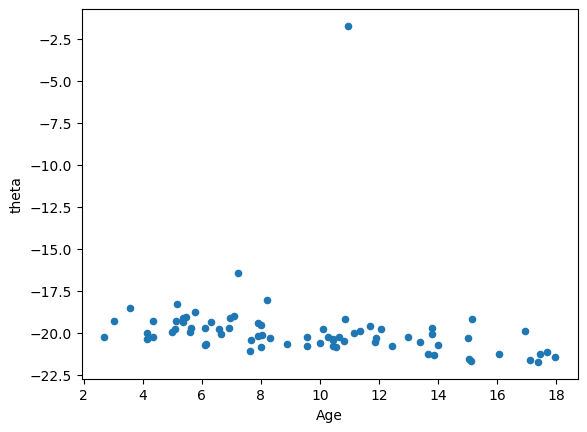

In [197]:
df[['theta', 'Age']].plot(kind='scatter', x='Age', y='theta')

In [198]:
df[['theta', 'Age']].corr()

,theta,Age
theta,1.000000,-0.182807
Age,-0.182807,1.000000
